In [274]:
import numpy as np
import pandas as pd

# Import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
sns.set_style("white") 

In [275]:
import os

print(os.listdir())

['.DS_Store', '.gitkeep', '01_clean.py', '02_fixation_detection.py', '03_drift_correction.py', '04_analysis.py', 'DataProcessing.ipynb', 'qc_events.py', '__init__.py']


RAW DATA

In [ ]:
#load the data
data_path = "../data/raw/subject-14.tsv"

data = pd.read_csv(data_path, sep='\t')

csv_path = "../data/raw/subject-14.csv"

trial_data = pd.read_csv(csv_path)


data["trial"] = (data["USER"] == "FIXATION_ONSET").cumsum()
analysis_data = data.copy()
analysis_data["USER"].value_counts()


print(trial_data.shape)
print(trial_data.head())

(108, 150)
                 AN Code                        RN        acc   accuracy  \
0   <AN>Frauen</AN>   C6    <RN>Pfleger*innen</RN>  undefined  undefined   
1   <AN>Frauen</AN>   C6  <RN>Einwohner*innen</RN>  undefined  undefined   
2  <AN>Männern</AN>   C3      <RN>Expertinnen</RN>  undefined  undefined   
3   <AN>Männer</AN>   C1      <RN>Professoren</RN>  undefined  undefined   
4  <AN>Männern</AN>   C3   <RN>Einwohnerinnen</RN>  undefined  undefined   

  an_found  an_height  an_line           an_text  an_width  ...       title  \
0      NaN        NaN      NaN               NaN       NaN  ...  Experiment   
1      NaN        NaN      NaN               NaN       NaN  ...  Experiment   
2      NaN        NaN      NaN               NaN       NaN  ...  Experiment   
3      NaN        NaN      NaN               NaN       NaN  ...  Experiment   
4     True       53.0      4.0  <AN>Männern</AN>     158.0  ...  Experiment   

   total_correct  total_response_time  total_responses tr

In [277]:
trial_data_gezeigt = trial_data[trial_data["skip_trial"] == 0]
display(trial_data_gezeigt)

,AN,Code,RN,acc,accuracy,an_found,an_height,an_line,an_text,an_width,...,title,total_correct,total_response_time,total_responses,trial_counter,width,word,word_height,word_spacing,word_width
4,<AN>Männern</AN>,C3,<RN>Einwohnerinnen</RN>,undefined,undefined,True,53.0,4.0,<AN>Männern</AN>,158.0,...,Experiment,0,0,0,1,1920,Debatten.,53.0,25.0,197.0
10,<AN>Männer</AN>,C5,<RN>Professor*innen</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,2,1920,diskutiert.,53.0,25.0,243.0
11,<AN>Frauen</AN>,C2,<RN>Polizisten</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,3,1920,verhandelt.,53.0,25.0,244.0
12,<AN>Frauen</AN>,C4,<RN>Expertinnen</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,4,1920,bewertet.,53.0,25.0,197.0
31,<AN>Männer</AN>,C5,<RN>Dozent*innen</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,5,1920,an.,53.0,25.0,59.0
36,<AN>Frauen</AN>,C6,<RN>Krankenpfleger*innen</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,6,1920,diskutiert.,53.0,25.0,243.0
39,<AN>Frauen</AN>,C4,<RN>Pflegerinnen</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,7,1920,diskutiert.,53.0,25.0,243.0
53,<AN>Männer</AN>,C3,<RN>Expertinnen</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,8,1920,bewertet.,53.0,25.0,197.0
55,<AN>Männer</AN>,C1,<RN>Aktivisten</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,9,1920,geprüft.,53.0,25.0,175.0
56,<AN>Männer</AN>,C1,<RN>Ingenieure</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,10,1920,diskutiert.,53.0,25.0,243.0


In [278]:
data.head(500)

,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,REYEX,REYEY,REYEZ,RPUPILD,RPUPILV,CX,CY,CS,USER,trial
0,521552,3509.08936,2452293170658,0.43010,0.76731,3508.98901,0.08716,3999,0,0.49777,...,0.03969,0.00518,0.70484,0.00375,1,1.38828,0.41181,0,0,0
1,521553,3509.09644,2452293239712,0.43010,0.76731,3508.98901,0.08716,3999,0,0.49777,...,0.03969,0.00518,0.70484,0.00375,1,1.38828,0.41181,0,START_TRIAL,0
2,521554,3509.10474,2452293323703,0.00000,0.00000,3508.98901,0.08716,3999,0,0.49777,...,0.03969,0.00518,0.70484,0.00375,1,1.38828,0.41181,0,NaN,0
3,521555,3509.11353,2452293410483,0.00000,0.00000,3508.98901,0.08716,3999,0,0.49777,...,0.03969,0.00518,0.70484,0.00375,1,1.38828,0.41181,0,NaN,0
4,521556,3509.12231,2452293500420,0.00000,0.00000,3508.98901,0.08716,3999,0,0.49777,...,0.03969,0.00518,0.70484,0.00375,1,1.38828,0.41181,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,522047,3512.41235,2452326398588,0.66445,0.44036,3512.21802,0.19434,4015,1,0.70326,...,0.04665,0.00966,0.67769,0.00329,1,1.38828,0.41181,0,NaN,0
496,522048,3512.41895,2452326465642,0.66380,0.44198,3512.21802,0.20093,4015,1,0.70407,...,0.04764,0.00993,0.67882,0.00291,1,1.38828,0.41181,0,NaN,0
497,522049,3512.42554,2452326532679,0.66591,0.44275,3512.21802,0.20752,4015,1,0.77402,...,0.04764,0.00993,0.67882,0.00345,1,1.38828,0.41181,0,NaN,0
498,522050,3512.43237,2452326599286,0.66730,0.47370,3512.21802,0.20752,4015,0,0.74919,...,0.04764,0.00993,0.67882,0.00325,1,1.38828,0.41181,0,NaN,0


In [279]:
data["trial"] = (data["USER"] == "START_TRIAL").cumsum()
data[data["USER"].notna()][["TIME","USER","trial"]].head(30)

,TIME,USER,trial
0,3509.08936,0,0
1,3509.09644,START_TRIAL,1
2431,3525.40015,INSTRUCTION_ONSET,1
2461,3525.61060,FIXATION_ONSET,1
2838,3528.13306,SENTENCE_ONSET,1
6656,3553.71362,TEXT_ONSET,1
6728,3554.19580,FIXATION_ONSET,1
7115,3556.78809,SENTENCE_ONSET,1
11388,3585.40967,TEXT_ONSET,1
11401,3585.49683,FIXATION_ONSET,1


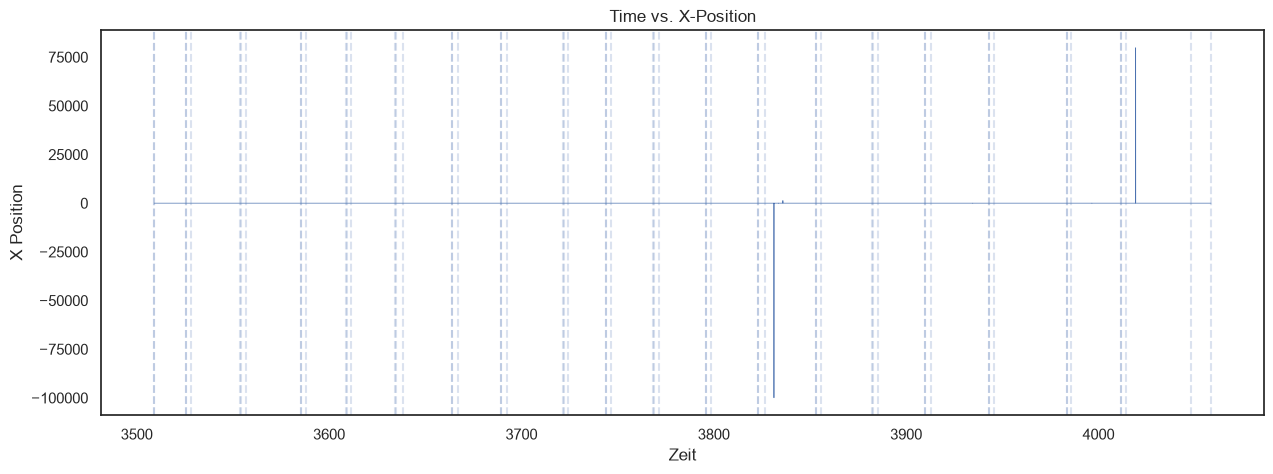

In [280]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    analysis_data["TIME"],
    analysis_data["BPOGX"],
    linewidth=0.5
)

for _, row in analysis_data.iterrows():

    if pd.notna(row["USER"]):

        plt.axvline(
            row["TIME"],
            alpha=0.2,
            linestyle="--"
        )

plt.xlabel("Zeit")
plt.ylabel("X Position")
plt.title("Time vs. X-Position")

plt.show()

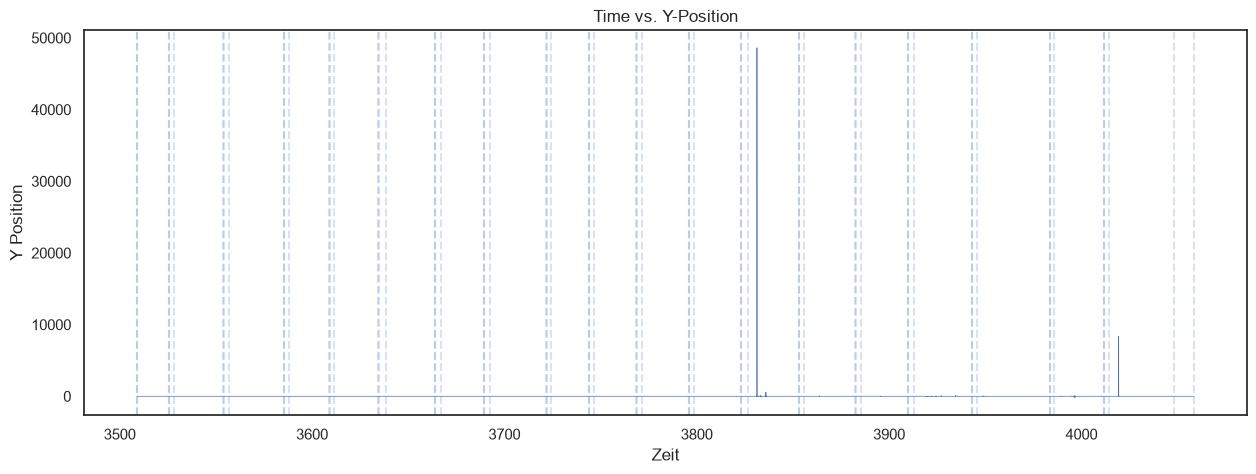

In [281]:
plt.figure(figsize=(15,5))

plt.plot(
    analysis_data["TIME"],
    analysis_data["BPOGY"],
    linewidth=0.5
)

for _, row in analysis_data.iterrows():

    if pd.notna(row["USER"]):

        plt.axvline(
            row["TIME"],
            alpha=0.2,
            linestyle="--"
        )

plt.xlabel("Zeit")
plt.ylabel("Y Position")
plt.title("Time vs. Y-Position")

plt.show()

             TIME               USER   delta_t
0      3509.08936                  0       NaN
1      3509.09644        START_TRIAL   0.00708
2431   3525.40015  INSTRUCTION_ONSET  16.30371
2461   3525.61060     FIXATION_ONSET   0.21045
2838   3528.13306     SENTENCE_ONSET   2.52246
6656   3553.71362         TEXT_ONSET  25.58056
6728   3554.19580     FIXATION_ONSET   0.48218
7115   3556.78809     SENTENCE_ONSET   2.59229
11388  3585.40967         TEXT_ONSET  28.62158
11401  3585.49683     FIXATION_ONSET   0.08716
11776  3588.00854     SENTENCE_ONSET   2.51171
14907  3608.98730         TEXT_ONSET  20.97876
14920  3609.07446     FIXATION_ONSET   0.08716
15260  3611.35181     SENTENCE_ONSET   2.27735
18693  3634.36694         TEXT_ONSET  23.01513
18780  3634.94971     FIXATION_ONSET   0.58277
19302  3638.44629     SENTENCE_ONSET   3.49658
23103  3663.93311         TEXT_ONSET  25.48682
23133  3664.13403     FIXATION_ONSET   0.20092
23563  3667.01416     SENTENCE_ONSET   2.88013


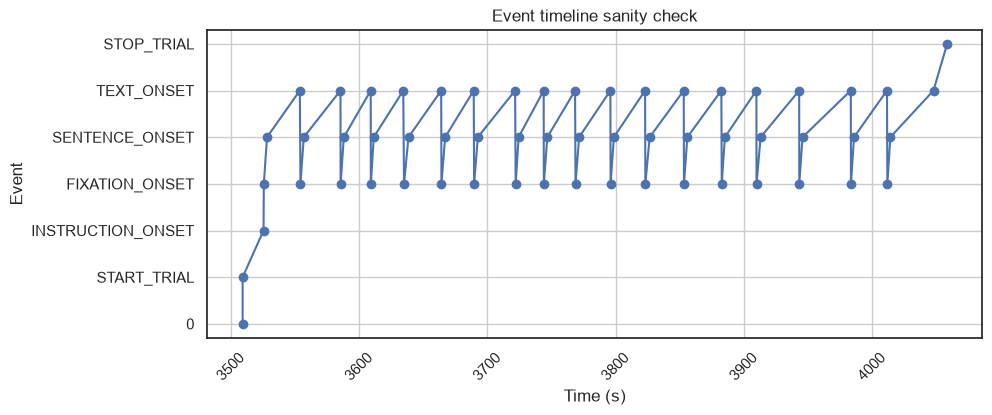

In [282]:
import pandas as pd

# only relevent events
logs = analysis_data[
    analysis_data["USER"].notna()
].copy()

# sort after time
logs = logs.sort_values("TIME")

# Timedifference
logs["delta_t"] = logs["TIME"].diff()

# Show event
print(logs[["TIME", "USER", "delta_t"]].head(20))
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(logs["TIME"], logs["USER"], marker="o")

plt.xticks(rotation=45)
plt.title("Event timeline sanity check")
plt.xlabel("Time (s)")
plt.ylabel("Event")

plt.grid(True)

plt.show()

In [283]:
width = 1920      # RESOLUTION
height = 1080

margin = 150
font_size = 39

box_width = width - (2 * margin)

text_start_x = -(box_width / 2)
text_start_y = -height / 2 + 250

cross_x = text_start_x
cross_y = text_start_y + (font_size / 2)

centre_x = width/2 + cross_x
centre_y = height/2 + cross_y

cross_x_norm = centre_x / width
cross_y_norm = centre_y / height

print(cross_x_norm, cross_y_norm)

0.078125 0.24953703703703703


FROM HERE WE USE DATA WITHOUT INVALID SAMPLES

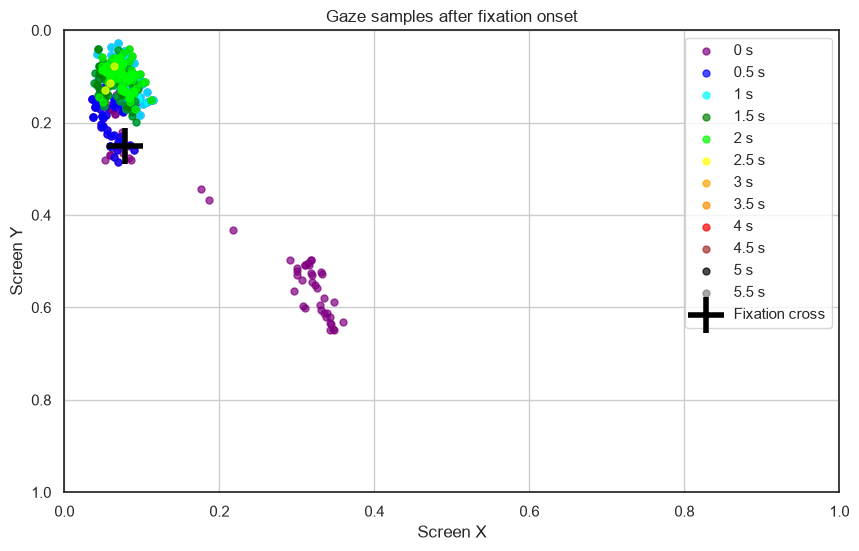

In [284]:
fixation_events = analysis_data[
    analysis_data["USER"] == "FIXATION_ONSET"
]

t0 = fixation_events["TIME"].iloc[0]

sentence_onset = analysis_data[
    (analysis_data["USER"] == "SENTENCE_ONSET") &
    (analysis_data["TIME"] > t0)
]["TIME"].iloc[0]

window = analysis_data[
    (analysis_data["TIME"] >= t0) &
    (analysis_data["TIME"] < sentence_onset)
].copy()



# Time for fixationcross
window["time_after_onset"] = window["TIME"] - t0

window = window[
    (window["BPOGV"] == 1) &
    (window["BPOGX"] >= 0) &
    (window["BPOGX"] <= 1) &
    (window["BPOGY"] >= 0) &
    (window["BPOGY"] <= 1)
]

# Resolution

SCREEN_W = 1920   
SCREEN_H = 1080

font_size = font_size
margin = 150

box_width = SCREEN_W - (2 * margin)

text_start_x = -(box_width / 2)
text_start_y = -SCREEN_H / 2 + 250

cross_x = text_start_x
cross_y = text_start_y + (font_size / 2)

centre_x = SCREEN_W / 2 + cross_x
centre_y = SCREEN_H / 2 + cross_y

cross_x_norm = centre_x / SCREEN_W
cross_y_norm = centre_y / SCREEN_H


plt.figure(figsize=(10, 6))


# different colors over time
colors = {
    0: "purple",
    0.5: "blue",
    1: "cyan",
    1.5: "green",
    2: "lime",  
    2.5: "yellow", 
    3: "orange", 
    3.5: "darkorange", 
    4: "red", 
    4.5: "brown",
    5: "black",
    5.5: "grey",     
}


# Gaze Points coloring
for ms, color in colors.items():

    samples = window[
        (window["time_after_onset"] >= ms) &
        (window["time_after_onset"] < ms + 1)
    ]

    plt.scatter(
        samples["BPOGX"],
        samples["BPOGY"],
        c=color,
        s=25,
        alpha=0.7,
        label=f"{ms} s"
    )


# Fixationcross
plt.scatter(
    cross_x_norm,
    cross_y_norm,
    c="black",
    marker="+",
    s=700,
    linewidths=4,
    label="Fixation cross"
)


plt.xlim(0,1)
plt.ylim(1,0)

plt.xlabel("Screen X")
plt.ylabel("Screen Y")
plt.title("Gaze samples after fixation onset")
plt.legend()
plt.grid(True)

plt.show()

    trial  n_samples  mean_dist_px  median_dist_px  std_dist_px
0       1        149    156.305351      157.594533    35.122309
1       2        149     84.111802       76.887867    42.621702
2       3        149     53.647764       47.374869    33.089248
3       4        149     99.842887      100.526898    39.106938
4       5        137     98.824729       88.503762    66.651795
5       6        129    122.779719      111.939431    64.706080
6       7        142    143.773530      156.711023    55.548201
7       8        149    163.998808      128.289695   122.574162
8       9         80    442.747870      307.616532   328.857427
9      10        149     85.815377       83.230185    43.721967
10     11        149     94.593931       96.021193    39.041104
11     12        141     88.162154       83.404029    39.757621
12     13        136    109.771454      107.514976    49.229638
13     14        149     94.505738       87.973025    48.246117
14     15        115     70.487596      

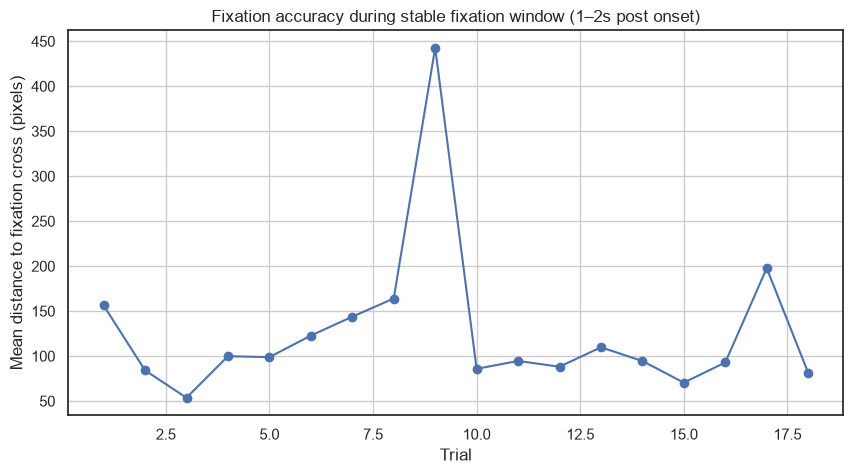

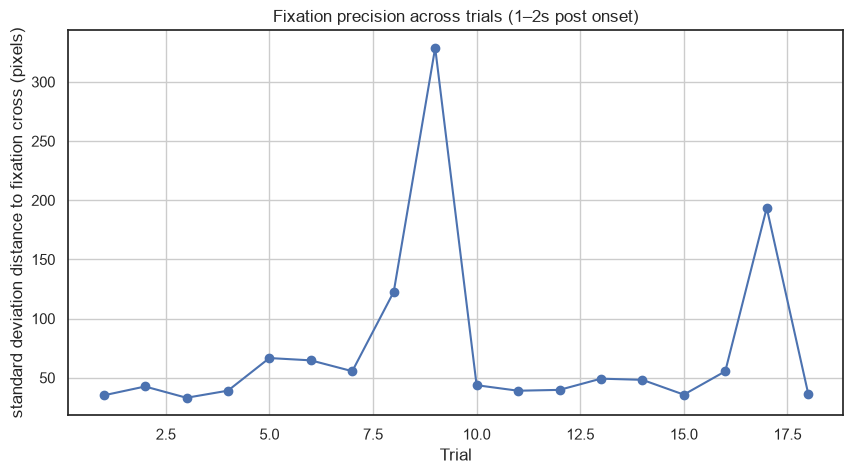

In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 
# Resolution
 

SCREEN_W = 1920
SCREEN_H = 1080

 
# Position of fixationcross
 

font_size = font_size
margin = 150

box_width = SCREEN_W - (2 * margin)

text_start_x = -(box_width / 2)
text_start_y = -SCREEN_H / 2 + 250

cross_x = text_start_x
cross_y = text_start_y + (font_size / 2)

centre_x = SCREEN_W / 2 + cross_x
centre_y = SCREEN_H / 2 + cross_y

cross_x_norm = centre_x / SCREEN_W
cross_y_norm = centre_y / SCREEN_H

 
# Fixation Events
 

fixation_events = analysis_data[
    analysis_data["USER"] == "FIXATION_ONSET"
].copy()

results = []

 
# Accuracy pro Fixation
 

for i, (_, fix) in enumerate(
    fixation_events.iterrows()
):

    t0 = fix["TIME"]

    # only use the first seconds:
    # 1s to 2s after Fixation-Onset

    next_sentence = analysis_data[
        (analysis_data["USER"] == "SENTENCE_ONSET") &
        (analysis_data["TIME"] > t0)
    ]

    if next_sentence.empty:
        continue

    sentence_onset = next_sentence["TIME"].iloc[0]

    window = analysis_data[
        (analysis_data["TIME"] >= t0 + 1.0) &
        (analysis_data["TIME"] < min(t0 + 2.0, sentence_onset))
    ].copy()

    # remove invalid samples

    window = window[
        (window["BPOGV"] == 1) &
        (window["BPOGX"] >= 0) &
        (window["BPOGX"] <= 1) &
        (window["BPOGY"] >= 0) &
        (window["BPOGY"] <= 1)
    ]

    if len(window) == 0:
        continue

    # Distanz to Fixationscross

    window["dist_px"] = np.sqrt(

        ((window["BPOGX"] - cross_x_norm) * SCREEN_W) ** 2 +

        ((window["BPOGY"] - cross_y_norm) * SCREEN_H) ** 2

    )

    results.append({

        "trial": i + 1,

        "n_samples": len(window),

        "mean_dist_px": window["dist_px"].mean(),

        "median_dist_px": window["dist_px"].median(),

        "std_dist_px": window["dist_px"].std()

    })

 
# Table
 

accuracy_df = pd.DataFrame(results)

print(accuracy_df)

 
# Summary
 

print("\nSummary:\n")

print(
    accuracy_df[
        [
            "mean_dist_px",
            "median_dist_px",
            "std_dist_px"
        ]
    ].describe()
)

 
# Plot
 

plt.figure(figsize=(10,5))

plt.plot(
    accuracy_df["trial"],
    accuracy_df["mean_dist_px"],
    marker="o"
)

plt.xlabel("Trial")
plt.ylabel("Mean distance to fixation cross (pixels)")
plt.title("Fixation accuracy during stable fixation window (1–2s post onset)")

plt.grid(True)

plt.show()

plt.figure(figsize=(10,5))

plt.plot(
    accuracy_df["trial"],
    accuracy_df["std_dist_px"],
    marker="o"
)

plt.xlabel("Trial")
plt.ylabel("standard deviation distance to fixation cross (pixels)")
plt.title("Fixation precision across trials (1–2s post onset)")

plt.grid(True)
plt.show()

Sentences OVER TIME DARSTELLUNG     

Keep in mind that matplot isnt rendering the sentences the same as opensesame so the sentences might not always be in the right position but the aois are.

rn_x1       370.0
rn_y1      -173.0
rn_x2       756.0
rn_y2      -120.0
an_x1      -131.0
an_y1        61.0
an_x2         1.0
an_y2       114.0
spill_x1      1.0
spill_y1     61.0
spill_x2    133.0
spill_y2    114.0
Name: 0, dtype: float64


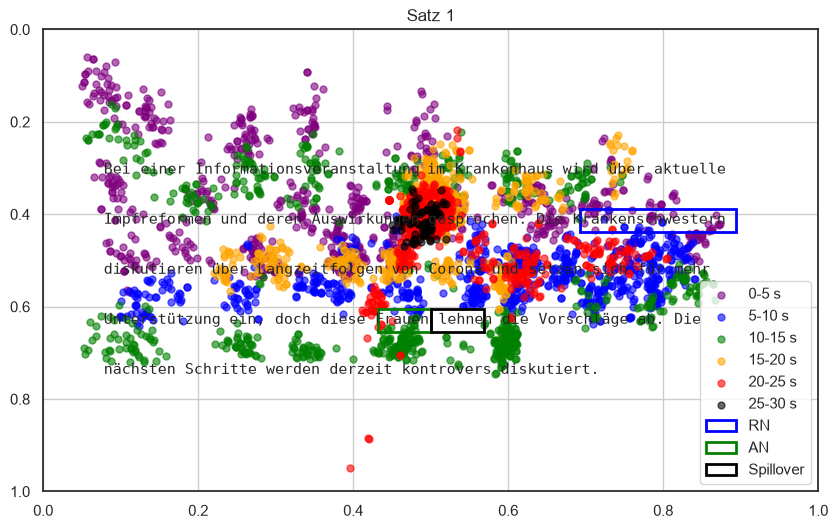

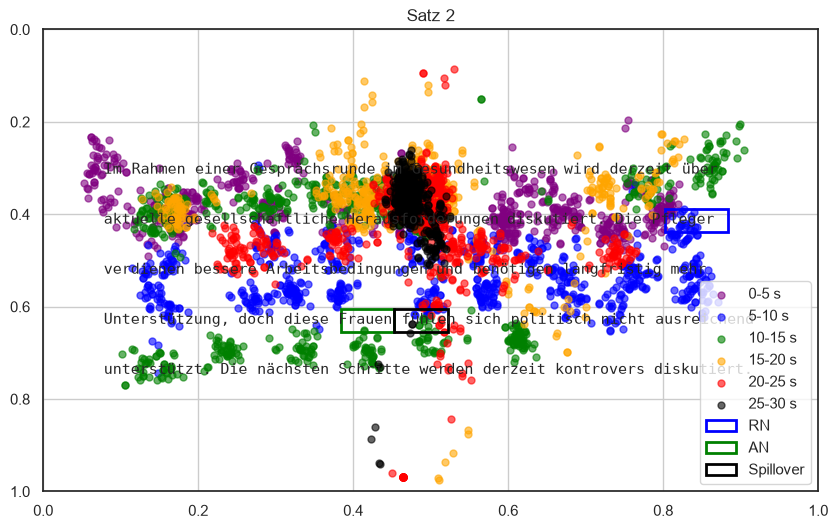

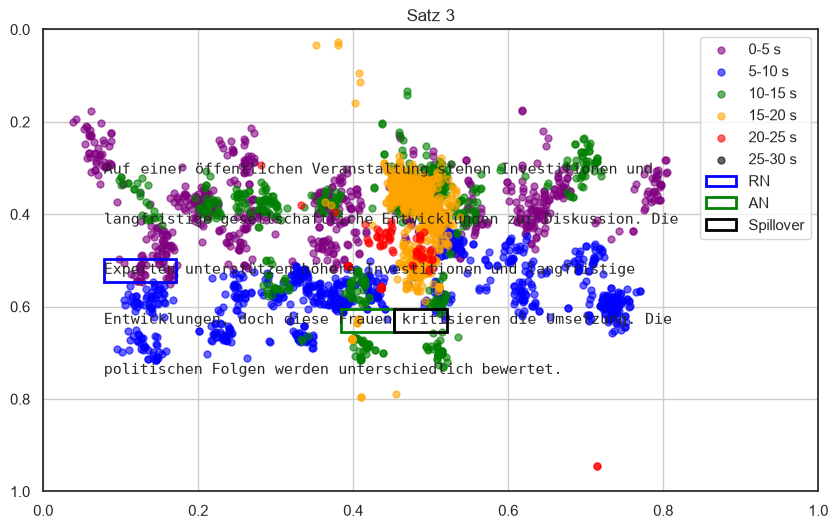

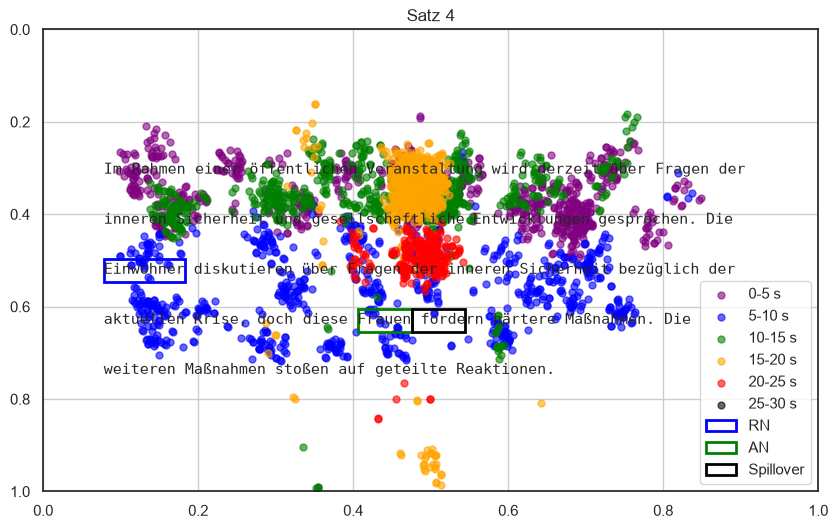

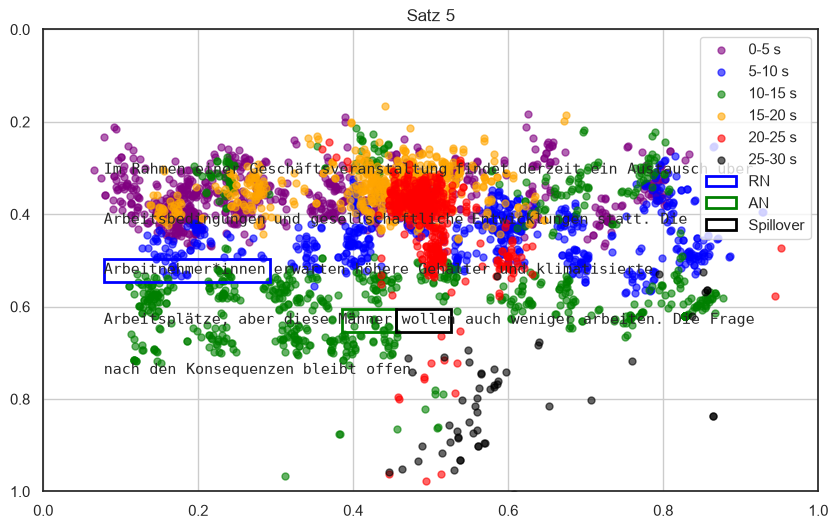

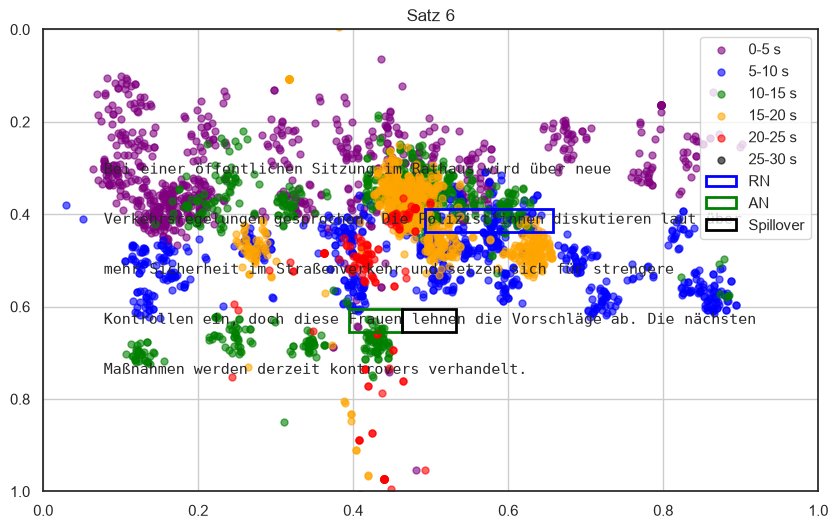

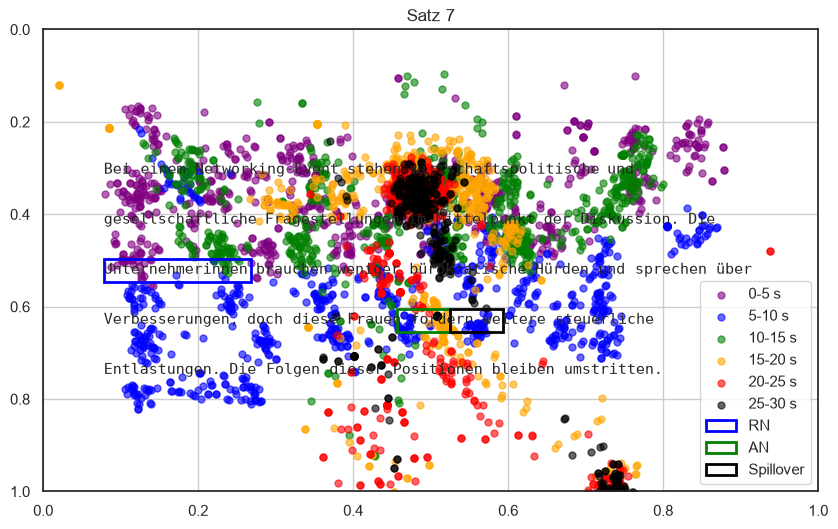

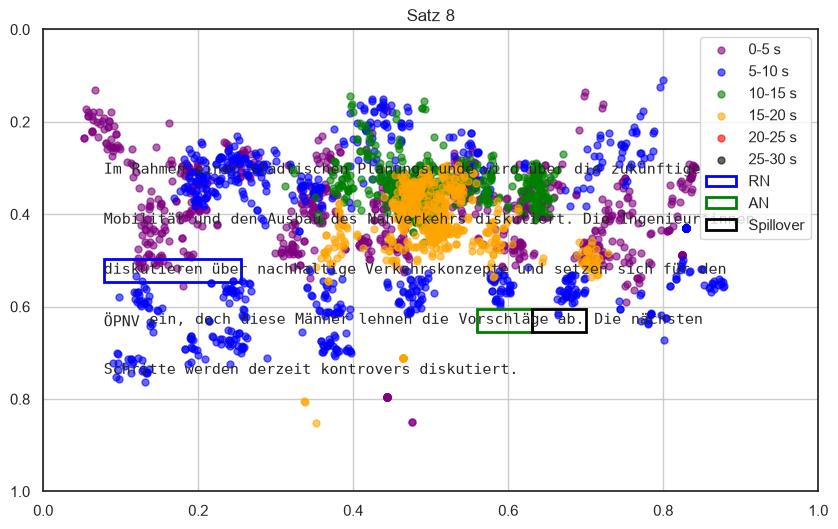

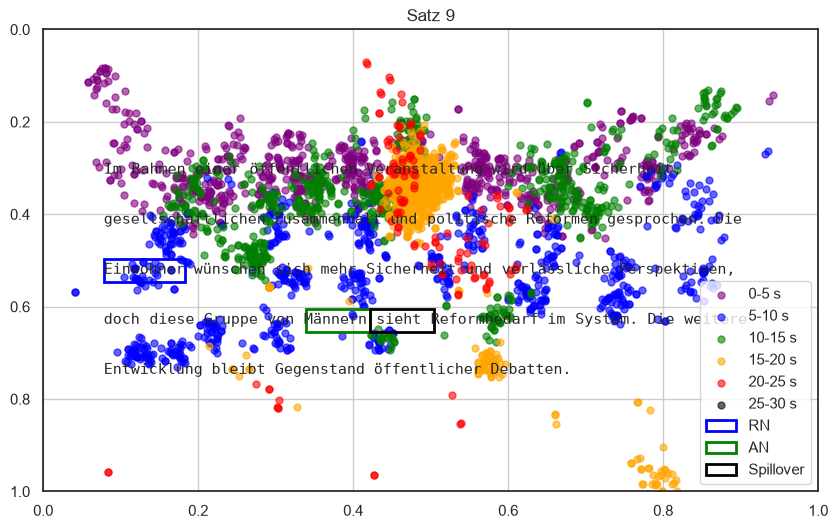

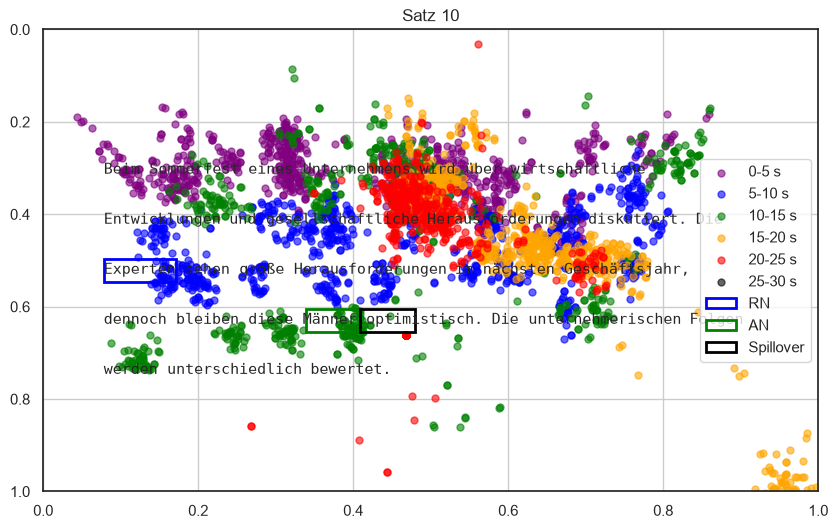

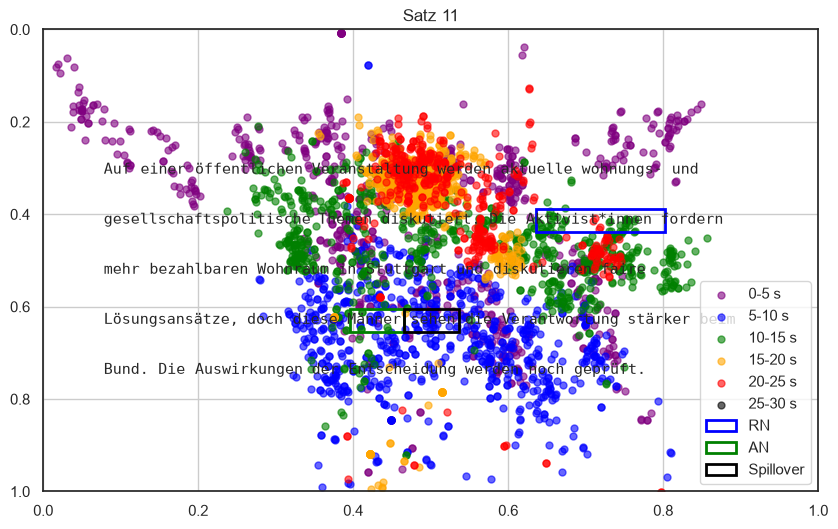

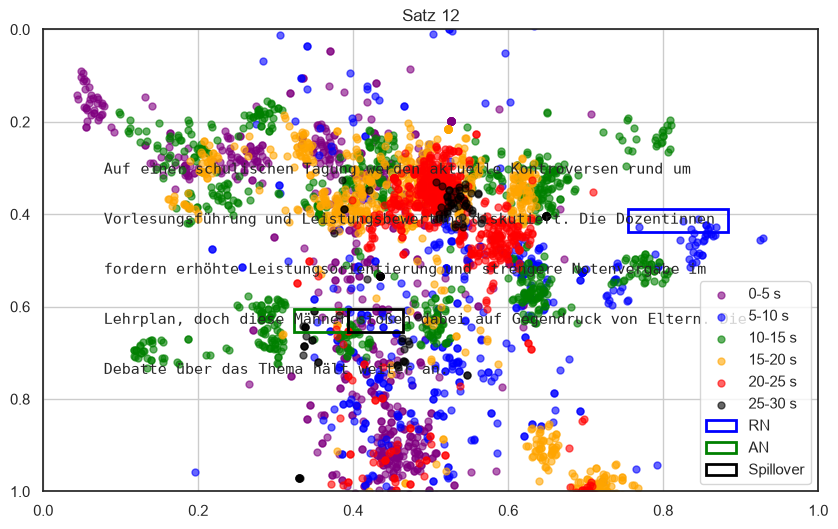

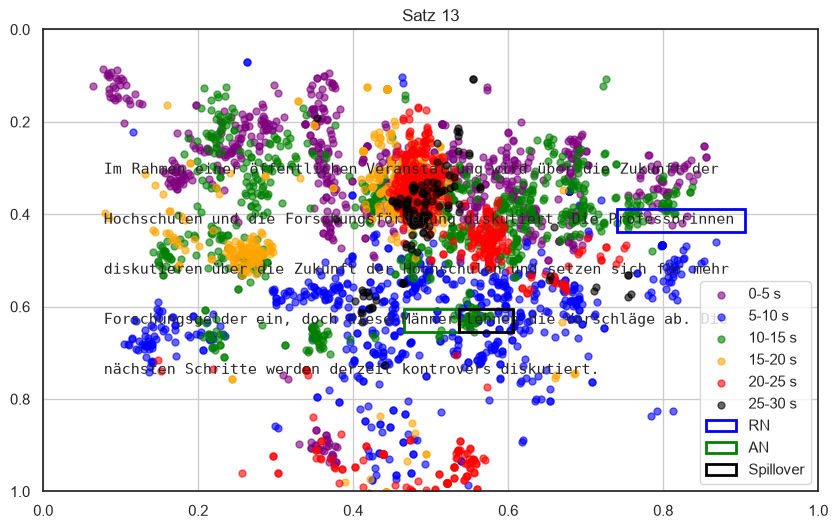

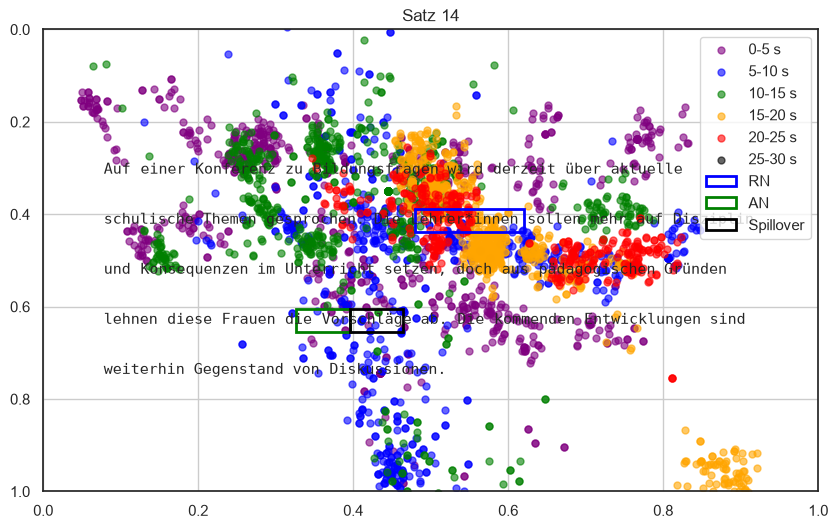

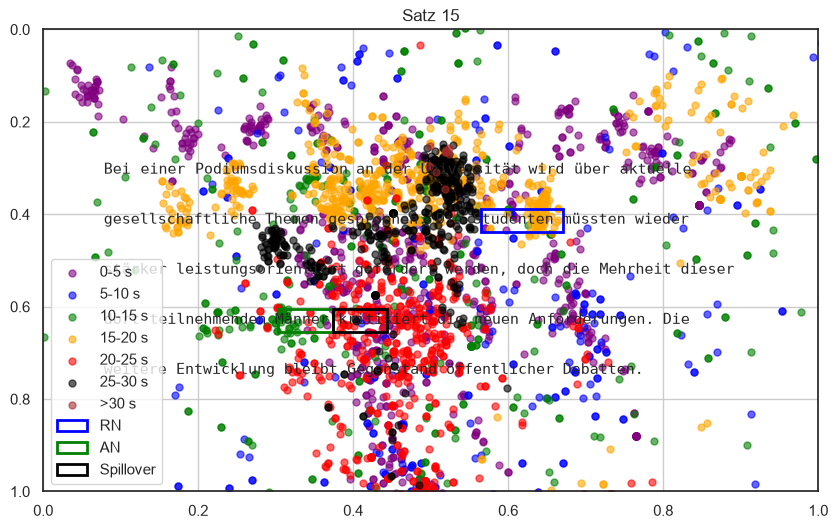

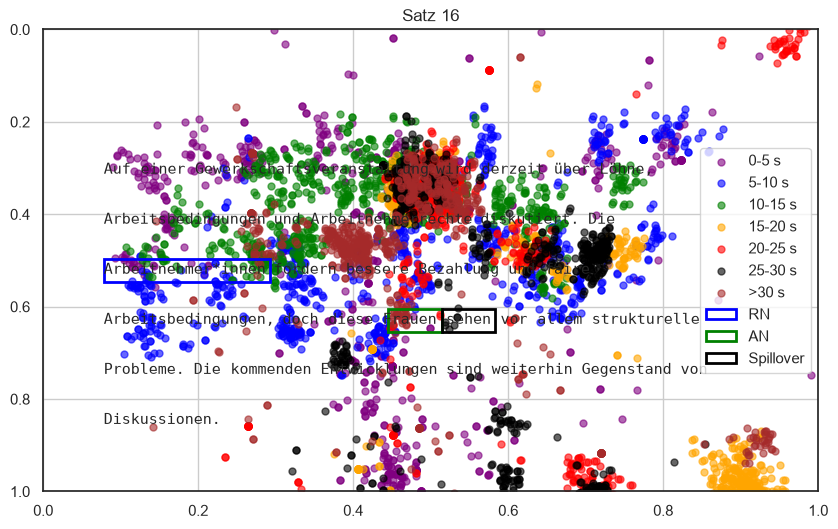

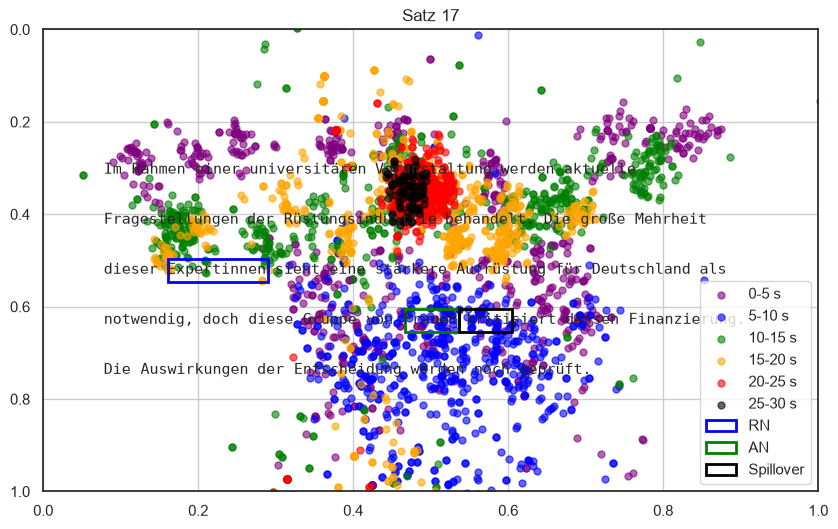

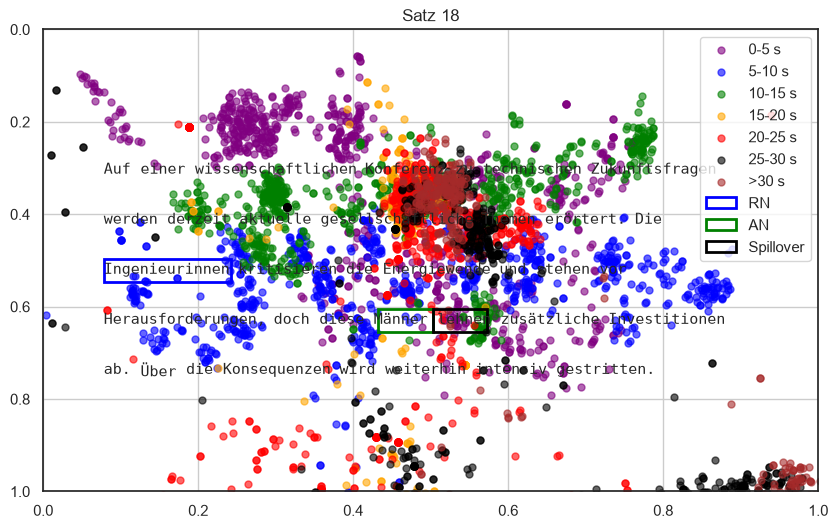

In [286]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# CSV loading
 
csv_path = "../data/raw/subject-1.csv"
trial_data = pd.read_csv(csv_path)

# Nur echte Trials behalten
trial_data = trial_data[trial_data["trial_counter"] > 0].reset_index(drop=True)


aoi_cols = [
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2",
    "spill_x1","spill_y1","spill_x2","spill_y2"
]

trial_data[aoi_cols] = (
    trial_data
    .groupby("trial_counter")[aoi_cols]
    .bfill()
)

sentence_data = (
    trial_data
    .drop_duplicates(subset="trial_counter")
    .reset_index(drop=True)
)
print(sentence_data.loc[0, [
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2",
    "spill_x1","spill_y1","spill_x2","spill_y2"
]])
 
# Events
 

sentence_events = analysis_data[
    analysis_data["USER"] == "SENTENCE_ONSET"
].copy()


text_events = analysis_data[
    analysis_data["USER"] == "TEXT_ONSET"
]

sentence_events = sentence_events.reset_index(drop=True)

 
# RN / AN Positionings
 

for col in [
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2",
    "spill_x1","spill_y1","spill_x2","spill_y2"
]:

    sentence_events[col] = sentence_data[col].iloc[:18].values


# RESOLUTION 1920 x 1080

SCREEN_W = 1920
SCREEN_H = 1080


font_size = 39
word_spacing = 25

margin = 150

box_width = SCREEN_W - 2*margin


line_spacing = font_size * 3

 
# Koordinates
 
def conv_x(x):

    return (
        SCREEN_W/2 + x
    ) / SCREEN_W


def conv_y(y):

    return (
        SCREEN_H/2 + y
    ) / SCREEN_H

# Sentences
 
for i, (_, event) in enumerate(
    sentence_events.iloc[:18].iterrows()
):


    t0 = event["TIME"]



    next_text = text_events[
        text_events["TIME"] > t0
    ]


    if len(next_text)==0:
        continue



    t1 = next_text["TIME"].iloc[0]



    window = analysis_data[
        (analysis_data["TIME"] >= t0) &
        (analysis_data["TIME"] < t1)
    ].copy()

    plt.figure(figsize=(10,6))


    plt.xlim(0,1)
    plt.ylim(1,0)

      
    # Sentences
      
    import re

    sentence = sentence_data.loc[i,"sentence_text"]


    rn_text = str(sentence_data.loc[i,"RN"])
    an_text = str(sentence_data.loc[i,"AN"])

    # RN / AN Tags removal
    rn_text = re.sub(
        r"<RN>|</RN>",
        "",
        rn_text
    )

    an_text = re.sub(
        r"<AN>|</AN>",
        "",
        an_text
    )

    # text between the tags

    sentence = re.sub(
        r"<RN>.*?</RN>",
        rn_text,
        sentence
    )


    sentence = re.sub(
        r"<AN>.*?</AN>",
        an_text,
        sentence
    )



    sentence = sentence.replace(
        "<RN>",
        rn_text
    ).replace(
        "</RN>",
        ""
    )


    sentence = sentence.replace(
        "<AN>",
        an_text
    ).replace(
        "</AN>",
        ""
    )

    words = sentence.split()

    position_x = -(box_width/2)

    position_y = -SCREEN_H/2 + 310

    for word in words:


        # try to get the text the same size
        word_width = len(word) * 22



        current_width = (
            position_x + box_width/2
        )

        if current_width + word_width > box_width:


            position_x = -(box_width/2)

            position_y += line_spacing

        plt.text(

            conv_x(position_x),

            conv_y(position_y),

            word,

            fontsize=11,

            family="monospace",

            ha="left",

            va="top"

        )

        position_x += (
            word_width + word_spacing
        )


    # Gaze colored over reading time
      

    window["time_after"] = window["TIME"] - t0


    bins = [0, 5, 10, 15, 20, 25, 30]

    colors = [
        "purple",
        "blue",
        "green",
        "orange",
        "red",
        "black"
    ]


    for j in range(len(bins)-1):

        samples = window[
            (window["time_after"] >= bins[j]) &
            (window["time_after"] < bins[j+1])
        ]

        plt.scatter(
            samples["BPOGX"],
            samples["BPOGY"],
            color=colors[j],
            s=25,
            alpha=0.6,
            label=f"{bins[j]}-{bins[j+1]} s"
        )


    # If Sentences were read longer than 30 seconds
    samples = window[
        window["time_after"] >= 30
    ]

    if len(samples) > 0:

        plt.scatter(
            samples["BPOGX"],
            samples["BPOGY"],
            color="brown",
            s=25,
            alpha=0.6,
            label=">30 s"
        )
       
     
    # RN Box 
     

    if pd.notna(event["rn_x1"]):

        rn = patches.Rectangle(

            (
                conv_x(event["rn_x1"]),
                conv_y(event["rn_y2"])
            ),

            (event["rn_x2"] - event["rn_x1"]) / SCREEN_W,

            (event["rn_y2"] - event["rn_y1"]) / SCREEN_H,

            fill=False,

            linewidth=2,

            edgecolor="blue",

            label="RN"

        )


        plt.gca().add_patch(rn)

    # AN Box 
     

    if pd.notna(event["an_x1"]):

        an = patches.Rectangle(

            (
                conv_x(event["an_x1"]),
                conv_y(event["an_y2"])
            ),

            (event["an_x2"] - event["an_x1"]) / SCREEN_W,

            (event["an_y2"] - event["an_y1"]) / SCREEN_H,

            fill=False,

            linewidth=2,

            edgecolor="green",

            label="AN"

        )

        plt.gca().add_patch(an)

    if pd.notna(event["spill_x1"]):

        spill = patches.Rectangle(

            (
                conv_x(event["spill_x1"]),
                conv_y(event["spill_y2"])
            ),

            (event["spill_x2"] - event["spill_x1"]) / SCREEN_W,

            (event["spill_y2"] - event["spill_y1"]) / SCREEN_H,

            fill=False,

            linewidth=2,

            edgecolor="black",


            label="Spillover"

        )

        plt.gca().add_patch(spill)

    plt.title(
        f"Satz {i+1}"
    )

    plt.legend()

    plt.grid()

    plt.show()

In [287]:
print(sentence_data.loc[0, [
    "font_size",
    "word_spacing",
    "word_width",
    "word_height",
    "width",
    "height"
]])
print(sentence_data.loc[2,[
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2"
]])

font_size         39.0
word_spacing      25.0
word_width       243.0
word_height       53.0
width           1920.0
height          1080.0
Name: 0, dtype: float64
rn_x1   -810.0
rn_y1    -56.0
rn_x2   -631.0
rn_y2     -3.0
an_x1   -223.0
an_y1     61.0
an_x2    -91.0
an_y2    114.0
Name: 2, dtype: float64


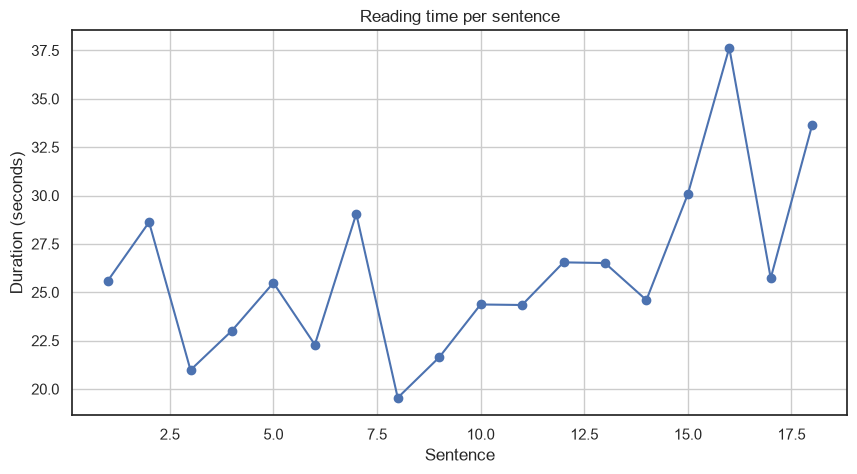

In [288]:
import matplotlib.pyplot as plt

durations = []
sentence_ids = []

for i, (_, event) in enumerate(sentence_events.iterrows()):

    t0 = event["TIME"]

    next_text = text_events[text_events["TIME"] > t0]

    if len(next_text) == 0:
        continue

    t1 = next_text["TIME"].iloc[0]

    # Only valid samples
    valid_samples = analysis_data[
        (analysis_data["TIME"] >= t0) &
        (analysis_data["TIME"] < t1) &
        (analysis_data["BPOGV"] == 1)
    ]

    if valid_samples.empty:
        continue

    durations.append(t1 - t0)
    sentence_ids.append(i + 1)

plt.figure(figsize=(10,5))
plt.plot(sentence_ids, durations, marker="o")
plt.xlabel("Sentence")
plt.ylabel("Duration (seconds)")
plt.title("Reading time per sentence")
plt.grid(True)
plt.show()

GO Past Time

In [289]:
def go_past_time(window, x1, y1, x2, y2, exit_x=None):

    window = window.sort_values("TIME").reset_index(drop=True)

    x_min = conv_x(x1)
    x_max = conv_x(x2)

    y_top = conv_y(y2)
    y_bottom = conv_y(y1)

    y_min = min(y_top, y_bottom)
    y_max = max(y_top, y_bottom)

    inside = (
        (window["BPOGX"] >= x_min) &
        (window["BPOGX"] <= x_max) &
        (window["BPOGY"] >= y_min) &
        (window["BPOGY"] <= y_max)
    )

    if not inside.any():
        return np.nan

    first = inside.idxmax()

    start_time = window.loc[first, "TIME"]

    if exit_x is None:
        exit_x = x2

    right_border = conv_x(exit_x)

    for i in range(first + 1, len(window)):

        if window.loc[i, "BPOGX"] > right_border:
            return window.loc[i, "TIME"] - start_time

    return window.iloc[-1]["TIME"] - start_time

rn_gpt = go_past_time(
    window,
    event["rn_x1"],
    event["rn_y1"],
    event["rn_x2"],
    event["rn_y2"]
)
an_gpt = go_past_time(
    window,
    event["an_x1"],
    event["an_y1"],
    event["spill_x2"],      # AOI till end of Spillover
    event["an_y2"],
    exit_x=event["spill_x2"]
)

results = []

for i, (_, event) in enumerate(sentence_events.iloc[:19].iterrows()):

    ...

    rn_gpt = go_past_time(
        window,
        event["rn_x1"],
        event["rn_y1"],
        event["rn_x2"],
        event["rn_y2"]
    )

    
    an_gpt = go_past_time(
    window,
    min(event["an_x1"], event["spill_x1"]),
    min(event["an_y1"], event["spill_y1"]),
    max(event["an_x2"], event["spill_x2"]),
    max(event["an_y2"], event["spill_y2"]),
    exit_x=max(event["an_x2"], event["spill_x2"])
    )

    results.append({
        "sentence": i + 1,
        "RN_GPT": rn_gpt,
        "AN_GPT": an_gpt
    })

results = pd.DataFrame(results)
print(results)

    sentence   RN_GPT   AN_GPT
0          1  2.16357  0.68335
1          2      NaN  0.60254
2          3  0.06689  0.60254
3          4  0.06689  0.46240
4          5  0.06689  0.60254
5          6  0.20093  0.46240
6          7  0.06689  0.56250
7          8  0.06689  0.44873
8          9  0.06689  0.40210
9         10  0.06689  0.40210
10        11  2.36401  0.46240
11        12      NaN  0.42212
12        13  1.96240  0.66285
13        14  0.20093  0.42212
14        15  0.20093  0.41529
15        16  0.06689  0.56250
16        17  0.22094  0.66285
17        18  0.06689  0.68335


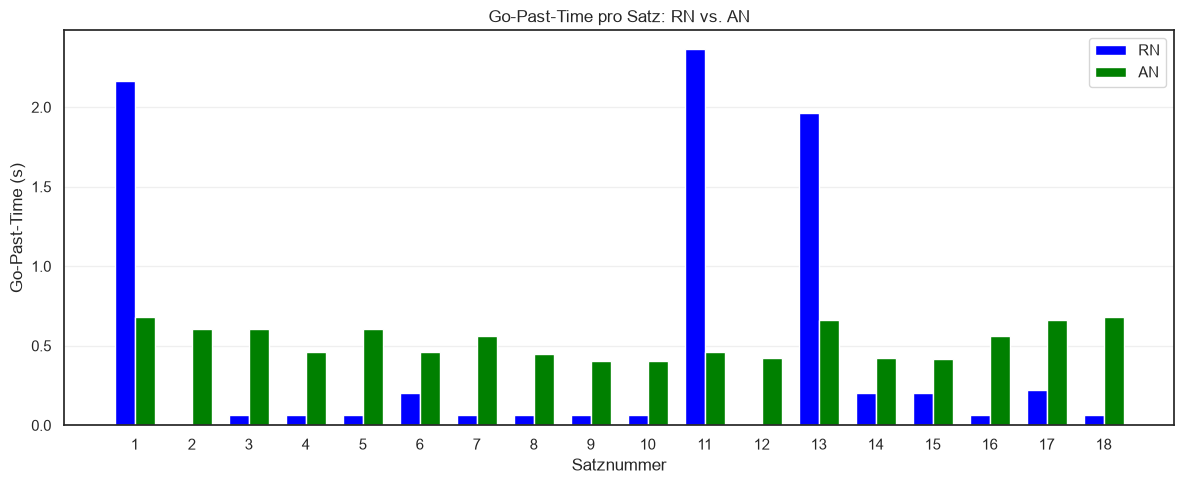

In [290]:
import matplotlib.pyplot as plt
import numpy as np

df = results.copy()

sentences = df["sentence"]

x = np.arange(len(sentences))

bar_width = 0.35

plt.figure(figsize=(12,5))

# RN Balken
plt.bar(
    x - bar_width/2,
    df["RN_GPT"],
    width=bar_width,
    label="RN",
    color="blue"
)

# AN Balken
plt.bar(
    x + bar_width/2,
    df["AN_GPT"],
    width=bar_width,
    label="AN",
    color="green"
)


plt.xticks(
    x,
    sentences
)

plt.xlabel("Satznummer")
plt.ylabel("Go-Past-Time (s)")

plt.title("Go-Past-Time pro Satz: RN vs. AN")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()